# 🤖 AI-powered Meta Software Development Notebook

Here’s the English translation:

This notebook demonstrates how to use AI to automatically generate a complete software system from a business problem:

1. **Problem Analysis**: Generate problem statements, user personas, and requirement documents.
2. **Requirement Classification**: Distinguish between functional and non-functional requirements.
3. **Design Documentation**: Automatically select and generate UML diagrams.
4. **Code Generation**: Automatically generate the Flask API backend.
5. **Frontend Generation**: Automatically generate the website frontend.
6. **Image Generation**: Automatically generate visual images.

---

## Setup & Environment
Prepare the Python environment, import required libraries, and initialize the LLM client. This ensures reproducibility.

In [1]:
import os
import sys
import json
from pathlib import Path

# Add project path to Python path
sys.path.insert(0, os.path.abspath('.'))

# Check and install Pillow
try:
    from PIL import Image
    print("✅ Pillow ready")
except Exception:
    print("⚠️ Installing Pillow...")
    %pip install pillow
    print("✅ Pillow installed")

# Import utils
try:
    from utils import (
        get_completion,
        load_environment,
        setup_llm_client,
        clean_llm_output,
        render_plantuml_diagram
    )
    print("✅ Utils imported")
except Exception as e:
    print(f"❌ Import failed: {e}")
    raise

# Load env variables
try:
    load_environment()
    print("✅ Env loaded")
except Exception as e:
    print(f"❌ Env failed: {e}")
    raise

# Initialize LLM client
client, model_name, api_provider = None, None, None
try:
    client, model_name, api_provider = setup_llm_client("openai/gpt-5.2")
    print(f"✅ LLM ready: {api_provider} - {model_name}")
except Exception as e:
    print(f"❌ LLM failed: {e}")

✅ Pillow ready
✅ Utils imported
✅ Loaded environment from c:\Users\sino\Desktop\DTS114 CW\meta_flask_api_generator\2469832-Xiaoyao_Wang\2469832-xiaoyao_wang\Task1\.env
✅ Env loaded
✅ Loaded environment from c:\Users\sino\Desktop\DTS114 CW\meta_flask_api_generator\2469832-Xiaoyao_Wang\2469832-xiaoyao_wang\Task1\.env
✅ LLM Client configured: Using 'apifree' with model 'openai/gpt-5.2'
✅ LLM ready: apifree - openai/gpt-5.2


## Section 1: Requirements

**Purpose:** Define the business problem and generate all requirement documentation.

**Output:**

- `artifacts/problem_statement.md`
- `artifacts/personas.md`
- `artifacts/prd.md`
- `artifacts/requirements_classification.md`
- `artifacts/user_stories.json`


## 📋 1. **Phase 1: Define Business Problem** 


- Input your business problem description

In [2]:
# Define business problem (your market stall system)
business_problem = """
We need a market ordering system where the platform manages multiple independent stalls, each with its own database.
Users can browse the market, select items from different stalls to add to the cart, and after submitting an order, the system will automatically split it into sub-orders by stall.
Merchants can view and update the status of their stall's sub-orders.
The system should also generate an order splitting flow chart automatically.
"""

print("Business problem defined:")
print("="*50)
print(business_problem)
print("="*50)

Business problem defined:

We need a market ordering system where the platform manages multiple independent stalls, each with its own database.
Users can browse the market, select items from different stalls to add to the cart, and after submitting an order, the system will automatically split it into sub-orders by stall.
Merchants can view and update the status of their stall's sub-orders.
The system should also generate an order splitting flow chart automatically.



## 🎯 Phase 2: **Generate Problem Statement**

 - AI generates a clear problem statement


In [3]:
if client and 'business_problem' in globals():
    print("--- Generating Problem Statement ---")
    prompt = f"Given the business problem below, generate one clear and concise problem statement.\nBusiness Problem: {business_problem}"
    problem_statement = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    print("Problem Statement:")
    print("="*50)
    print(problem_statement)
    print("="*50)

    # Save output to artifact file
    os.makedirs('artifacts', exist_ok=True)
    with open('artifacts/problem_statement.md', 'w', encoding='utf-8') as f:
        f.write(problem_statement)
    print("✅ Problem statement saved to artifacts/problem_statement.md")
else:
    print("Skipping step: LLM client or business problem is not available.")

--- Generating Problem Statement ---
Problem Statement:
Design and implement a multi-stall market ordering system where customers can add items from different independently managed stalls (each with its own database) into a single cart and checkout once, after which the platform automatically splits the purchase into per-stall sub-orders that stall merchants can view and update, and automatically produces a flowchart documenting the order-splitting process.
✅ Problem statement saved to artifacts/problem_statement.md


## 👥 Phase 3: **Generate User Personas** 

- AI creates user personas based on requirement


In [4]:
if client and 'problem_statement' in globals():
    print("--- Generating Personas ---")
    prompt = (
        "Generate 3-4 user personas for the solution using this format:\n"
        "Personas: <one-sentence intro>\n\n"
        "1. **Role Title**\n   - **Responsibilities:** ...\n   - **Needs:** ...\n\n"
        "2. **Role Title**\n   - **Responsibilities:** ...\n   - **Needs:** ...\n\n"
        "Rules: Use single role titles only; no slashes (/) or combined titles. "
        "Keep each bullet concise.\n"
        f"Problem Statement: {problem_statement}"
    )
    personas = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    print(f"Personas:\n{personas}")

    # Save to file
    os.makedirs('artifacts', exist_ok=True)
    with open('artifacts/personas.md', 'w', encoding='utf-8') as f:
        f.write(personas)
    print("✅ Personas saved to artifacts/personas.md")
else:
    print("Skipping step because LLM client or problem statement is not available.")

--- Generating Personas ---
Personas:
Personas: Core users include shoppers placing a single mixed-stall order, merchants fulfilling their portion, and admins ensuring the split-and-sync workflow runs reliably.

1. **Customer**
   - **Responsibilities:** Browse stalls, add items to cart, checkout once, track overall order status.
   - **Needs:** One cart across stalls, clear totals and fees, consolidated tracking with per-stall updates.

2. **Merchant**
   - **Responsibilities:** Manage stall catalog and inventory, view assigned sub-orders, update fulfillment and pickup/delivery status.
   - **Needs:** Real-time sub-order feed, simple status updates, accurate item and payment breakdown per stall.

3. **Administrator**
   - **Responsibilities:** Configure stalls and integrations, monitor order-splitting jobs, resolve exceptions and disputes.
   - **Needs:** Audit logs per split, retry/rollback tools, dashboards for stuck or failed sub-orders.

4. **Developer**
   - **Responsibilities:**

## 📝 Phase 4: **Generate PRD**

 - AI generates Product Requirements Document


In [5]:
if client and 'problem_statement' in globals() and 'personas' in globals():
    print("--- Generating PRD ---")
    prompt = (
        "Write a PRD in markdown with these headings, each with 2-4 concise bullets:\n"
        "## Overview\n## Goals\n## Non-Goals\n## User Personas (brief)\n"
        "## Key Features\n## User Flows\n## Functional Requirements\n"
        "## Non-Functional Requirements\n## Constraints/Assumptions\n"
        "## Success Metrics\n## Open Questions\n\n"
        "Rules: Use only the headings above. No extra sections. Keep bullets short.\n"
        f"Problem Statement: {problem_statement}\n"
        f"Personas: {personas}"
    )
    prd = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3,
    )
    prd = clean_llm_output(prd, language='markdown')

    print('📝  (PRD):')
    print('='*50)
    print(prd)
    print('='*50)

    # Save to file
    os.makedirs('artifacts', exist_ok=True)
    with open('artifacts/prd.md', 'w', encoding='utf-8') as f:
        f.write(prd)
    print("✅ PRD saved to artifacts/prd.md")
else:
    print("Skipping step because LLM client, problem statement, or personas are not available.")

--- Generating PRD ---
📝  (PRD):
## Overview
- Single cart/checkout across multiple independently managed stalls (separate databases)
- Platform splits a paid order into per-stall sub-orders for merchant fulfillment
- Merchants view/update only their sub-orders; customer sees consolidated status
- System auto-generates a flowchart documenting the order-splitting process

## Goals
- Enable mixed-stall cart and one-time payment with correct totals/fees/taxes
- Create reliable, idempotent order-splitting and per-stall order sync
- Provide merchant tooling for fast sub-order fulfillment updates
- Auto-produce/export an always-up-to-date order-splitting flowchart

## Non-Goals
- Unifying or migrating stall databases into a single shared database
- Implementing full merchant POS/accounting beyond sub-order views and statuses
- Supporting complex multi-address shipping in v1 (beyond per-stall fulfillment rules)
- Building a general-purpose workflow engine for all business processes

## User P

## 📋 Phase 5:  **Classify Requirements** 

- AI classifies requirements as functional vs non-functional


In [6]:
if client and 'prd' in globals():
    print("--- Classifying Requirements ---")
    prompt = (
        "Analyze the following PRD and classify requirements into Functional Requirements and Non-Functional Requirements.\n"
        "Output format:\n"
        "## Functional Requirements\n"
        "- <requirement 1>\n"
        "- <requirement 2>\n"
        "...\n\n"
        "## Non-Functional Requirements\n"
        "- <requirement 1>\n"
        "- <requirement 2>\n"
        "...\n\n"
        "Definitions:\n"
        "- Functional Requirements: What the system must DO - specific behaviors, features, and functions.\n"
        "- Non-Functional Requirements: How the system must BE - qualities like performance, security, reliability.\n"
        f"PRD Content:\n{prd}"
    )
    requirements_classification = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )

    print('📋 Result:')
    print('='*50)
    print(requirements_classification)
    print('='*50)

    # Save to file
    with open('artifacts/requirements_classification.md', 'w', encoding='utf-8') as f:
        f.write(requirements_classification)
    print("✅ Requirements classification saved to artifacts/requirements_classification.md")
else:
    print("Skipping step because LLM client or PRD is not available.")

--- Classifying Requirements ---
📋 Result:
## Functional Requirements
- Support a multi-stall cart with items grouped by stall.
- Compute totals (items, fees, taxes) per stall and overall in the cart/checkout.
- Provide a unified checkout with one-time payment across multiple stalls.
- Create a single platform “parent” order for the customer at checkout.
- Split the paid parent order into per-stall sub-orders with itemized allocations.
- Sync/write each sub-order into the corresponding stall system via API/connector.
- Handle partial failures during sub-order sync (e.g., some stalls succeed, others fail) with retry behavior.
- Allow merchants to view/list only their own sub-orders (via merchant portal and/or API).
- Allow merchants to update sub-order fulfillment status (e.g., confirm/prepare/ready/shipped).
- Aggregate sub-order statuses into a consolidated customer-visible order status and show per-stall updates.
- Provide admin/developer tools to monitor split jobs, inspect failures

## 🧑‍🤝‍🧑 Phase 6: **Generate User Stories** 

- AI creates user stories with acceptance criteria


In [7]:
if client and 'prd' in globals():
    print("--- Generating User Stories ---")
    prompt = (
        "Return ONLY valid JSON with this schema:\n"
        "{\n  \"user_stories\": [\n    {\n      \"id\": 1,\n      \"role\": \"<role>\",\n"
        "      \"goal\": \"<goal>\",\n      \"benefit\": \"<benefit>\",\n"
        "      \"acceptance_criteria\": [\"<criteria>\", \"<criteria>\"]\n    }\n  ]\n}\n\n"
        "Rules: Provide 5-6 stories. Keep each field concise. No extra keys.\n"
        f"PRD: {prd}"
    )
    user_stories = get_completion(
        prompt, client, model_name, api_provider, temperature=0.3
    )
    user_stories = clean_llm_output(user_stories, language='json')

    print(f"User Stories:\n{user_stories}")

    # Save to file
    with open('artifacts/user_stories.json', 'w', encoding='utf-8') as f:
        f.write(user_stories)
    print("✅ User stories saved to artifacts/user_stories.json")
else:
    print("Skipping step because LLM client or PRD is not available.")

--- Generating User Stories ---
User Stories:
{
  "user_stories": [
    {
      "id": 1,
      "role": "Customer",
      "goal": "Add items from multiple stalls into one cart and checkout once",
      "benefit": "Pay one time with accurate totals and fees",
      "acceptance_criteria": [
        "Cart groups items by stall and shows per-stall subtotals plus overall total",
        "Checkout processes a single payment and creates one platform order"
      ]
    },
    {
      "id": 2,
      "role": "Platform",
      "goal": "Split a paid order into per-stall sub-orders and sync to each stall system",
      "benefit": "Merchants can fulfill independently without losing allocation accuracy",
      "acceptance_criteria": [
        "Sub-orders contain only that stall’s items with itemized taxes/fees allocations",
        "Each sub-order is created in the corresponding stall system via connector/API"
      ]
    },
    {
      "id": 3,
      "role": "Administrator",
      "goal": "Retry fail

## Section 2: Development

**Purpose:** Generate the software code and visualizations.

**Output:**

- `artifacts/diagrams/use_case_diagram.png`
- `artifacts/diagrams/activity_diagram.png`
- `artifacts/diagrams/sequence_diagram.png`
- `app/main.py` (Flask API)
- `app/templates/*.html` (Website pages)
- `app/static/images/hero_banner.png`


## 📊 Phase 7: **UML Diagram Type Selection** 

- AI automatically selects appropriate UML diagram types


In [8]:
if client and 'prd' in globals():
    print("--- Selecting UML Diagram Type ---")
    prompt = (
        "Analyze the following business requirement PRD, and select the appropriate diagram(s) from Use Case Diagram, Activity Diagram, Sequence Diagram.\n"
        "\n"
        "Judgment rules:\n"
        "1. If the content describes user interactions with the system, actors, and system functionalities/use cases → choose Use Case Diagram\n"
        "2. If the content describes business workflows, execution steps, branch logic and overall process flow → choose Activity Diagram\n"
        "3. If the content describes time-ordered interaction, message passing and collaboration between multiple modules/objects → choose Sequence Diagram\n"
        "\n"
        "Output format strictly:\n"
        "Selected Diagram: xxx\n"
        "Reason: xxx\n"
        "\n"
        "PRD Content:\n"
        f"{prd}"
    )
    diagram_selection = get_completion(
        prompt, client, model_name, api_provider, temperature=0.1
    )

    print('📊 UML choice result:')
    print('='*50)
    print(diagram_selection)
    print('='*50)

    # Parse the selection
    selected_diagram = "Activity Diagram"  # Default
    lines = diagram_selection.strip().split('\n')
    for line in lines:
        if line.startswith('Selected Diagram:'):
            selected_diagram = line.replace('Selected Diagram:', '').strip()
            break

    print(f"✅ Selected UML Diagram: {selected_diagram}")
else:
    selected_diagram = "Activity Diagram"
    print("⚠️ Using default diagram type: Activity Diagram")

--- Selecting UML Diagram Type ---
📊 UML choice result:
Selected Diagram: Use Case Diagram, Activity Diagram  
Reason: The PRD defines multiple personas (Customer, Merchant, Administrator, Developer) and the system functions they use (multi-stall cart/checkout, sub-order management, monitoring/retry, flowchart export) → Use Case Diagram. It also specifies end-to-end workflows with clear step progression and failure/retry paths (payment → split → create sub-orders → sync stalls → aggregate statuses; partial failure with retries; admin retry tooling) → Activity Diagram.
✅ Selected UML Diagram: Use Case Diagram, Activity Diagram


## 📈 Phase 8:**Generate UML Diagrams** 

- AI generates UML diagrams (Use Case, Activity, Sequence)


--- Generating UML Diagrams (using Phase 7 results) ---
Phase 7 selected: ['Use Case Diagram', 'Activity Diagram']

diagram 1: use case diagram
Prompt:
diagram 1: use case diagram
User Stories:
- Customer: Add items from multiple stalls into one cart and checkout once
- Platform: Split a paid order into per-stall sub-orders and sync to each stall system
- Administrator: Retry failed split/sync steps safely with full auditability
- Merchant: View and update only my stall’s sub-orders in real time
- Customer: Track one consolidated order with per-stall fulfillment visibility
- Developer: Auto-generate a versioned flowchart of the order-splitting logic on deploy/CI
Notation Requirements:
- Actors are shown as STICK FIGURES with names below
- Use cases are OVALS with descriptive names
- Draw a rectangle to represent the SYSTEM BOUNDARY
- Use <<includes>> stereotype for mandatory dependencies (when one use case requires another)
- Use <<extends>> stereotype for optional/conditional behavior

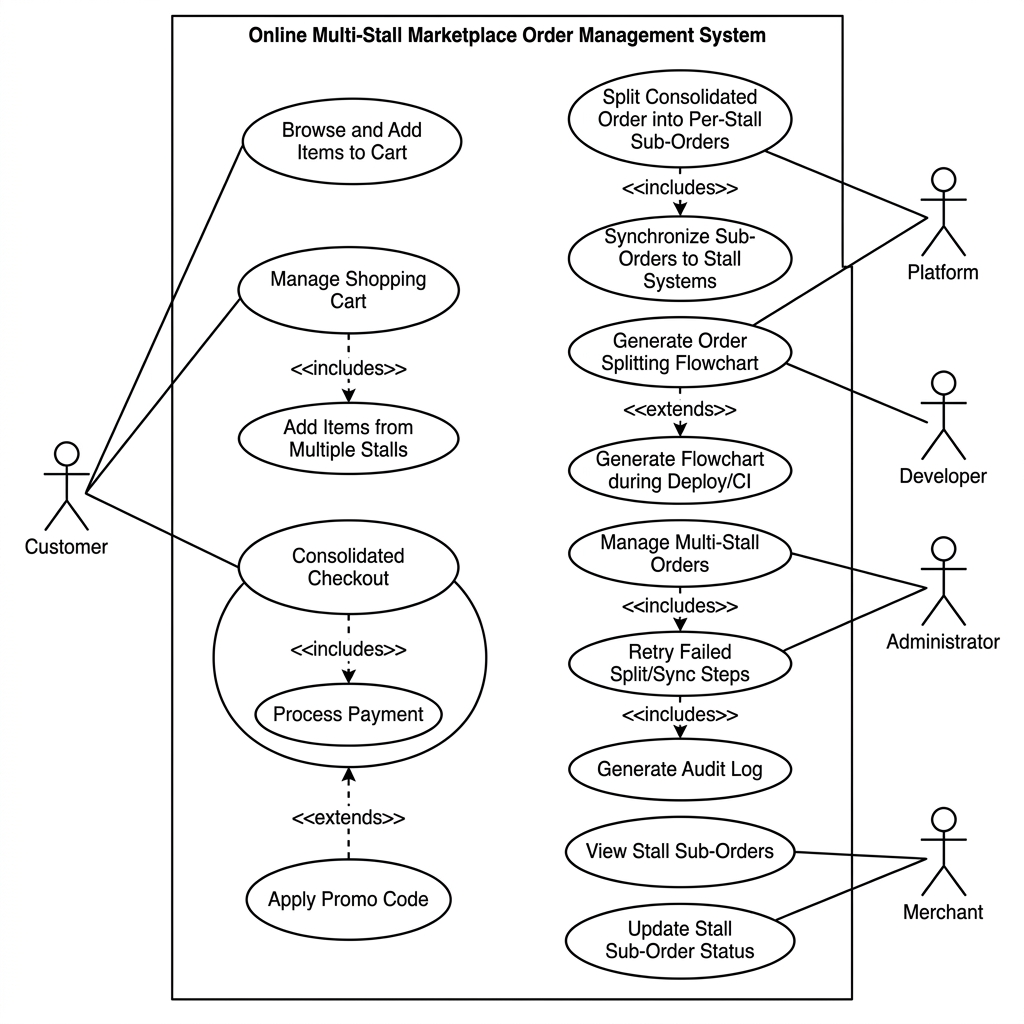


diagram 2: activity diagram
Prompt:
diagram 2: activity diagram
User Stories:
- Customer: Add items from multiple stalls into one cart and checkout once
- Platform: Split a paid order into per-stall sub-orders and sync to each stall system
- Administrator: Retry failed split/sync steps safely with full auditability
- Merchant: View and update only my stall’s sub-orders in real time
- Customer: Track one consolidated order with per-stall fulfillment visibility
- Developer: Auto-generate a versioned flowchart of the order-splitting logic on deploy/CI
Notation Requirements:
- Use START (filled circle) at the beginning
- Use activity rectangles for each step/action
- Use diamonds for decision points with Yes/No branches
- Use parallel fork (horizontal line) and join for concurrent actions
- Use END (filled circle with border) at the conclusion
- Use arrows (->) to show flow direction


Style: White background, black text, professional UML diagram, clear and readable.

Calling APIFree (goo

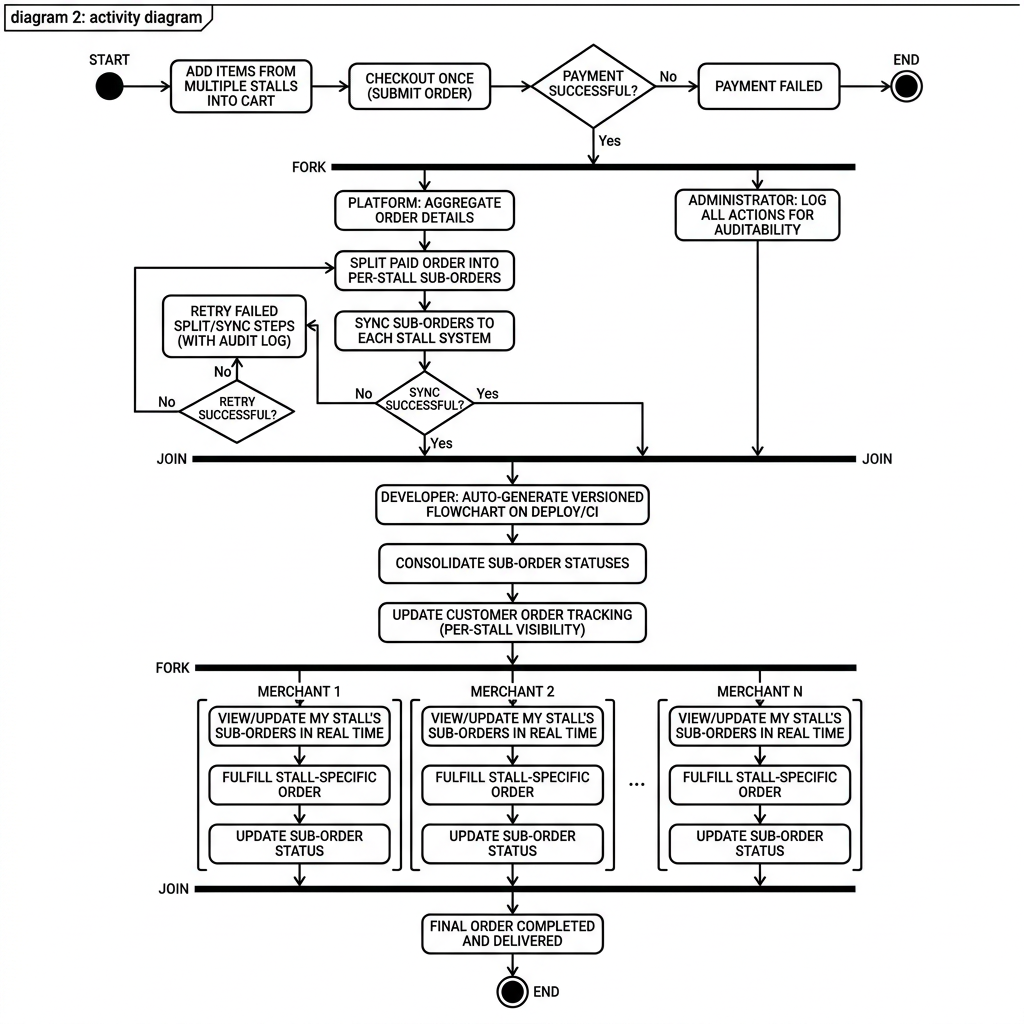


Done! Generated 2 UML diagrams


In [9]:
if client and 'selected_diagram' in globals() and 'prd' in globals():
    print("--- Generating UML Diagrams (using Phase 7 results) ---")
    
    # Step 1: Parse UML types from Phase 7 result
    diagram_types = [d.strip() for d in selected_diagram.split(',')]
    print(f"Phase 7 selected: {diagram_types}")
    
    # Step 2: Parse user stories for specific requirements
    stories_data = json.loads(user_stories) if isinstance(user_stories, str) else user_stories
    stories_list = stories_data if isinstance(stories_data, list) else stories_data.get('user_stories', [])
    stories_summary = "\n".join([f"- {s['role']}: {s['goal']}" for s in stories_list])
    
    # Step 3: Generate each diagram independently
    from utils import get_image_generation_completion
    from IPython.display import Image, display
    os.makedirs('artifacts/diagrams', exist_ok=True)
    
    for i, diagram_type in enumerate(diagram_types, 1):
        print(f"\n{'='*60}")
        print(f"diagram {i}: {diagram_type.lower()}")
        print(f"{'='*60}")
        
        # Type-specific requirements
        if 'Activity' in diagram_type:
            type_req = """Notation Requirements:
- Use START (filled circle) at the beginning
- Use activity rectangles for each step/action
- Use diamonds for decision points with Yes/No branches
- Use parallel fork (horizontal line) and join for concurrent actions
- Use END (filled circle with border) at the conclusion
- Use arrows (->) to show flow direction"""
        elif 'Sequence' in diagram_type:
            type_req = """Notation Requirements:
- Place actors on the LEFT side of the diagram
- Place system components across the TOP
- Draw vertical lifelines (dashed lines) for each participant
- Use horizontal arrows (solid for sync, dashed for return) for messages
- Label arrows with action descriptions
- Use activation boxes on lifelines to show processing time"""
        elif 'Use Case' in diagram_type:
            type_req = """Notation Requirements:
- Actors are shown as STICK FIGURES with names below
- Use cases are OVALS with descriptive names
- Draw a rectangle to represent the SYSTEM BOUNDARY
- Use <<includes>> stereotype for mandatory dependencies (when one use case requires another)
- Use <<extends>> stereotype for optional/conditional behavior
- A SOLID LINE between an Actor and Use Case indicates participation (no arrow needed)
- <<includes>> arrows point to the included use case
- <<extends>> arrows point to the extending use case
- No arrows between actors and use cases - it's a communication relationship, not a flow"""
        else:
            type_req = "Requirements: standard UML notation with clear labels"
        
        # Build prompt for this diagram
        prompt = f"""diagram {i}: {diagram_type.lower()}
User Stories:
{stories_summary}
{type_req}


Style: White background, black text, professional UML diagram, clear and readable."""
        
        print(f"Prompt:\n{prompt}\n")
        
        # Call API to generate this diagram
        print(f"Calling APIFree (google/nano-banana-2)...")
        img_path, err_msg = get_image_generation_completion(
            prompt, client, model_name='google/nano-banana-2', api_provider=api_provider
        )
        
        # Save and display
        if img_path:
            import shutil
            safe_name = diagram_type.lower().replace(' ', '_')
            final_path = f'artifacts/diagrams/{safe_name}.png'
            shutil.copy(img_path, final_path)
            print(f"Saved: {final_path}")
            print(f"\nGenerated {diagram_type}:")
            display(Image(filename=final_path, width=900))
        else:
            print(f"Failed: {err_msg}")
    
    print(f"\n{'='*60}")
    print(f"Done! Generated {len(diagram_types)} UML diagrams")
    print(f"{'='*60}")
else:
    print("Please run Phase 7 first to generate selected_diagram")

## 🔧 Phase 9: **Generate Flask API**

 - AI generates Flask REST API with endpoints


In [10]:
if client and 'user_stories' in globals():
    print("--- Generating Flask API ---")
    
    # Parse user stories
    try:
        stories_data = json.loads(user_stories) if isinstance(user_stories, str) else user_stories
        stories_list = stories_data if isinstance(stories_data, list) else stories_data.get('user_stories', [])
    except:
        print("Error parsing user stories")
        stories_list = []
    
    # Generate base app structure
    base_app = get_completion(
        "Create a minimal Flask app skeleton with: from flask import Flask, request, jsonify, send_from_directory; app = Flask(__name__); in-memory storage using order_db = []; Add CORS support with from flask_cors import CORS; CORS(app); Add a health check endpoint GET /health that returns {status: ok}. Keep it under 20 lines.",
        client, model_name, api_provider, temperature=0.3
    )
    base_app = clean_llm_output(base_app, language='python')
    
    print(f"✅ Generated base app structure")
    
    # Generate endpoints for each user story
    endpoints_code = []
    for i, story in enumerate(stories_list[:4], 1):
        story_text = f"Role: {story.get('role', '')}, Goal: {story.get('goal', '')}"
        print(f"  Generating endpoint {i}/{len(stories_list[:4])} for: {story.get('role', 'user')[:30]}...")
        
        endpoint_code = get_completion(
            f"Write 1-2 Flask endpoint functions for this user story: {story_text}. Use order_db list for storage. Return only the function code (e.g., @app.route decorated functions), no imports or app initialization. Keep under 25 lines. Ensure endpoints return JSON with proper status codes.",
            client, model_name, api_provider, temperature=0.3
        )
        endpoint_code = clean_llm_output(endpoint_code, language='python')
        endpoints_code.append(f"\n# Endpoint for Story {i}: {story.get('role', 'user')}\n{endpoint_code}")
    
    # Add a catch-all route to serve index.html
    frontend_route = """
# Serve frontend
@app.route('/')
def index():
    return send_from_directory('templates', 'index.html')

@app.route('/<path:filename>')
def serve_static(filename):
    return send_from_directory('.', filename)
"""
    
    # Combine all code
    main_py_code = base_app + "\n".join(endpoints_code) + frontend_route
    main_py_code += "\n\nif __name__ == '__main__':\n    app.run(host='0.0.0.0', debug=True, port=5000)"
    
    # Save to file
    os.makedirs('app', exist_ok=True)
    with open('app/main.py', 'w', encoding='utf-8') as f:
        f.write(main_py_code)
    print('✅ Saved: app/main.py')

    print("\n✅ Flask API generated successfully!")
else:
    print("Skipping step because LLM client or user_stories is not available.")

--- Generating Flask API ---
✅ Generated base app structure
  Generating endpoint 1/4 for: Customer...
  Generating endpoint 2/4 for: Platform...
  Generating endpoint 3/4 for: Administrator...
  Generating endpoint 4/4 for: Merchant...
✅ Saved: app/main.py

✅ Flask API generated successfully!


## 🌐 Phase 10: **Generate Website Frontend**

 - AI generates HTML templates


In [14]:
if client and 'user_stories' in globals():
    print("--- Intelligent Frontend Generation ---")
    
    # Step 1: Analyze user stories to determine frontend complexity
    stories_data = json.loads(user_stories) if isinstance(user_stories, str) else user_stories
    stories_list = stories_data if isinstance(stories_data, list) else stories_data.get('user_stories', [])
    
    # Extract unique roles from user stories
    roles = set()
    for story in stories_list:
        role = story.get('role', '').lower()
        if 'customer' in role or 'user' in role or 'guest' in role:
            roles.add('customer')
        elif 'merchant' in role or 'vendor' in role or 'seller' in role or 'stall' in role:
            roles.add('merchant')
        elif 'admin' in role or 'manager' in role or 'platform' in role:
            roles.add('admin')
        elif 'driver' in role or 'delivery' in role:
            roles.add('delivery')
        else:
            roles.add('user')
    
    roles = list(roles)
    num_roles = len(roles)
    print(f"Detected roles: {roles} ({num_roles} unique roles)")
    
    # Step 2: Generate hero banner image
    from utils import get_image_generation_completion
    
    # Safely get project title from prd
    if isinstance(prd, dict):
        project_title = prd.get('title', 'business')
    else:
        project_title = 'business'
    image_prompt = f"""Create a hero banner image for a {project_title} website.
Show a modern digital business scene with relevant imagery.
- Clean, professional illustration style
- White background with colorful accents
- Modern flat design aesthetic
- Minimalist approach"""
    
    print("Generating hero banner image...")
    img_path, img_err = get_image_generation_completion(
        image_prompt, client, model_name='google/nano-banana-2', api_provider=api_provider
    )
    
    hero_image_path = None
    if img_path:
        import shutil
        os.makedirs('app/static/images', exist_ok=True)
        hero_image_path = 'app/static/images/hero_banner.png'
        shutil.copy(img_path, hero_image_path)
        print(f"Hero banner saved: {hero_image_path}")
    
    # Step 3: Generate frontend based on complexity
    if num_roles <= 1:
        # Single-role: Generate unified single-page application
        print("\n=== Mode: Single-Page Application (SPA) ===")
        print("Generating unified frontend for single user role...")
        
        role_name = roles[0] if roles else 'user'
        role_features = ', '.join([s.get('goal', '') for s in stories_list[:3]])
        
        html_prompt = f"""Generate a complete, production-ready HTML5 single-page application.

Business Context:
- User Role: {role_name}
- Key Features: {role_features}

Requirements:
(1) Use Bootstrap 5 CSS framework via CDN
(2) Include hero banner image at: /static/images/hero_banner.png
(3) Modern responsive design with navigation
(4) All features in single page with section navigation
(5) Include all CSS in <style> tags
(6) Include all JavaScript in <script> tags
(7) Use Fetch API for HTTP requests to http://127.0.0.1:5000
(8) Handle API errors gracefully
(9) Single-page with smooth scrolling between sections
(10) Output ONLY the complete HTML document
"""
    else:
        # Multi-role: Generate integrated multi-page system
        print(f"\n=== Mode: Multi-Page Application (MPA) ===")
        print(f"Generating integrated frontend for {num_roles} user roles: {roles}")
        
        # Analyze which pages each role needs
        pages_needed = {
            'customer': ['index', 'login'],
            'merchant': ['login', 'merchant_dashboard'],
            'admin': ['login', 'admin_dashboard'],
            'delivery': ['login', 'delivery_dashboard'],
            'user': ['index', 'login']
        }
        
        pages_to_generate = set()
        for role in roles:
            pages_to_generate.update(pages_needed.get(role, ['index', 'login']))
        
        role_features = {}
        for story in stories_list:
            role = story.get('role', 'user').lower()
            if 'customer' in role or 'user' in role or 'guest' in role:
                role_features.setdefault('customer', []).append(story.get('goal', ''))
            elif 'merchant' in role or 'vendor' in role or 'seller' in role:
                role_features.setdefault('merchant', []).append(story.get('goal', ''))
            elif 'admin' in role or 'manager' in role:
                role_features.setdefault('admin', []).append(story.get('goal', ''))
            else:
                role_features.setdefault('user', []).append(story.get('goal', ''))
        
        features_text = '\n'.join([f"- {r}: {', '.join(f[:100] for f in fs[:2])}" for r, fs in role_features.items()])
        
        # Generate main index page
        print(f"Generating index.html for customers...")
        html_prompt = f"""Generate a complete, production-ready HTML5 homepage for a multi-role platform.

Business Features:
{features_text}

Requirements:
(1) Use Bootstrap 5 CSS framework via CDN
(2) Include hero banner at: /static/images/hero_banner.png - display image prominently without overlay/gradient covering it
(3) Hero section layout: centered title -> subtitle -> hero image -> subtitle (no text overlay on image)
(4) Navigation bar with: Home, Login, Register
(5) Display ALL FOUR role cards: Customer, Platform User (Ops/Engineer), Merchant (Stall Owner), Admin - all visible in 2-column responsive grid
(6) Use white text color (#ffffff) for all descriptive text and explanations for readability on dark background
(7) Modern responsive design with dark theme (dark background)
(8) Include all CSS in <style> tags
(9) Include all JavaScript in <script> tags
(10) Use Fetch API for HTTP requests
(11) Clear user journey steps for each role
(12) Use path-based navigation links (e.g., href='/login', href='/register', href='/') instead of anchor links
(13) Card hover effects and modern styling
(14) Output ONLY the complete HTML document
"""
    
    html_code = get_completion(
        html_prompt, client, model_name, api_provider, temperature=0.4
    )
    html_code = clean_llm_output(html_code, language='html')
    
    os.makedirs('app/templates', exist_ok=True)
    with open('app/templates/index.html', 'w', encoding='utf-8') as f:
        f.write(html_code)
    print(f"Saved: app/templates/index.html")
    
    # Step 4: Generate additional pages for multi-role scenario
    if num_roles > 1:
        print(f"\nGenerating additional pages for multi-role system...")
        
        # Generate login page
        login_prompt = f"""Generate a complete login/register HTML page for a multi-role platform.

Features by role:
{features_text}

Requirements:
(1) Use Bootstrap 5 CSS framework via CDN
(2) Include tabs or sections for different user types
(3) Login form with email/password
(4) Registration form with role selection
(5) Modern, professional design
(6) Include all CSS in <style> tags
(7) Include all JavaScript in <script> tags
(8) Store auth token in localStorage
(9) Redirect to appropriate dashboard after login
(10) Output ONLY the complete HTML document
"""
        
        login_code = get_completion(login_prompt, client, model_name, api_provider, temperature=0.4)
        login_code = clean_llm_output(login_code, language='html')
        with open('app/templates/login.html', 'w', encoding='utf-8') as f:
            f.write(login_code)
        print(f"Saved: app/templates/login.html")
        
        # Generate customer dashboard
        if 'customer' in roles or 'user' in roles:
            cust_features = role_features.get('customer', ['Browse products', 'Make orders', 'Track orders'])
            dash_prompt = f"""Generate a complete customer dashboard HTML page.

Customer Features: {', '.join(cust_features[:5])}

Requirements:
(1) Use Bootstrap 5 CSS framework via CDN
(2) Navigation bar with: Home, My Orders, Cart, Profile, Logout
(3) Display user orders history
(4) Shopping cart functionality
(5) Order status tracking
(6) Modern responsive design
(7) Include all CSS in <style> tags
(8) Include all JavaScript in <script> tags
(9) Use Fetch API for HTTP requests to http://127.0.0.1:5000
(10) Output ONLY the complete HTML document
"""
            
            dash_code = get_completion(dash_prompt, client, model_name, api_provider, temperature=0.4)
            dash_code = clean_llm_output(dash_code, language='html')
            with open('app/templates/user_dashboard.html', 'w', encoding='utf-8') as f:
                f.write(dash_code)
            print(f"Saved: app/templates/user_dashboard.html")
        
        # Generate merchant dashboard
        if 'merchant' in roles:
            merch_features = role_features.get('merchant', ['Manage orders', 'Update menu', 'View analytics'])
            merch_prompt = f"""Generate a complete merchant/vendor dashboard HTML page.

Merchant Features: {', '.join(merch_features[:5])}

Requirements:
(1) Use Bootstrap 5 CSS framework via CDN
(2) Navigation bar with: Dashboard, Orders, Menu, Settings, Logout
(3) Display incoming orders
(4) Menu/product management
    (5) Order status update controls
(6) Sales analytics overview
(7) Include all CSS in <style> tags
(8) Include all JavaScript in <script> tags
(9) Use Fetch API for HTTP requests to http://127.0.0.1:5000
(10) Output ONLY the complete HTML document
"""
            
            merch_code = get_completion(merch_prompt, client, model_name, api_provider, temperature=0.4)
            merch_code = clean_llm_output(merch_code, language='html')
            with open('app/templates/merchant_dashboard.html', 'w', encoding='utf-8') as f:
                f.write(merch_code)
            print(f"Saved: app/templates/merchant_dashboard.html")
        
        # Generate admin dashboard
        if 'admin' in roles:
            admin_prompt = """Generate a complete admin dashboard HTML page.

Admin Features: User management, System analytics, All orders overview, Platform settings

Requirements:
(1) Use Bootstrap 5 CSS framework via CDN
(2) Navigation bar with: Dashboard, Users, Orders, Settings, Logout
(3) Admin statistics overview
(4) User management table
(5) All orders overview
(6) Platform configuration
(7) Include all CSS in <style> tags
(8) Include all JavaScript in <script> tags
(9) Use Fetch API for HTTP requests to http://127.0.0.1:5000
(10) Output ONLY the complete HTML document
"""
            
            admin_code = get_completion(admin_prompt, client, model_name, api_provider, temperature=0.4)
            admin_code = clean_llm_output(admin_code, language='html')
            with open('app/templates/admin_dashboard.html', 'w', encoding='utf-8') as f:
                f.write(admin_code)
            print(f"Saved: app/templates/admin_dashboard.html")
        
        print(f"\nGenerated {num_roles} role pages")
    
    print(f"\nFrontend generation complete!")
    print(f"Mode: {'Multi-Page' if num_roles > 1 else 'Single-Page'} Application")
    print(f"Roles handled: {', '.join(roles)}")

else:
    print("Skipping step because LLM client or user_stories is not available.")

--- Intelligent Frontend Generation ---
Detected roles: ['merchant', 'user', 'customer', 'admin'] (4 unique roles)
Generating hero banner image...
Generating image... This may take a moment.
Task submitted. Request ID: 2062511204971319296
✅ Image generated in 20.06 seconds.
✅ Image saved to: artifacts\image_1780575983844.png
Hero banner saved: app/static/images/hero_banner.png

=== Mode: Multi-Page Application (MPA) ===
Generating integrated frontend for 4 user roles: ['merchant', 'user', 'customer', 'admin']
Generating index.html for customers...
Saved: app/templates/index.html

Generating additional pages for multi-role system...
Saved: app/templates/login.html
Saved: app/templates/user_dashboard.html
Saved: app/templates/merchant_dashboard.html
Saved: app/templates/admin_dashboard.html

Generated 4 role pages

Frontend generation complete!
Mode: Multi-Page Application
Roles handled: merchant, user, customer, admin


## 🔧 Phase 10.5: Flask API Enhancement

Enhance Flask API with authentication endpoints to support the frontend navigation and multi-role system.


In [15]:
if client and 'user_stories' in globals():
    print("--- Enhancing Flask API with Authentication ---")
    
    # Step 1: Analyze roles for API endpoints
    stories_data = json.loads(user_stories) if isinstance(user_stories, str) else user_stories
    stories_list = stories_data if isinstance(stories_data, list) else stories_data.get('user_stories', [])
    
    roles = set()
    for story in stories_list:
        role = story.get('role', '').lower()
        if 'customer' in role or 'user' in role or 'guest' in role:
            roles.add('customer')
        elif 'merchant' in role or 'vendor' in role or 'seller' in role:
            roles.add('merchant')
        elif 'admin' in role or 'manager' in role:
            roles.add('admin')
        else:
            roles.add('user')
    
    roles = list(roles)
    num_roles = len(roles)
    
    # Step 2: Generate enhanced Flask API
    api_enhancement_prompt = f"""Enhance this Flask API with authentication and multi-role support.

Current endpoints: Basic /health, /cart/checkout, /orders, /merchant/suborders
Detected roles: {roles}
Number of roles: {num_roles}

Requirements:
1. Add user database (in-memory dict: users = {{}} with fields: id, email, password_hash, role)
2. Add auth endpoints:
   - POST /api/register: Register new user (email, password, role)
   - POST /api/login: Login and return JWT-like token
   - POST /api/logout: Invalidate session
   - GET /api/me: Get current user info
3. Add role-based access control decorator
4. Protect existing endpoints based on role
5. Add endpoints for each role's dashboard needs
6. Keep existing endpoints working
7. Use simple token-based auth (no JWT library needed, use base64 encoding)
8. Return JSON responses with proper status codes
9. Add CORS support
10. Keep the existing code structure and add new code below

Output the COMPLETE enhanced main.py code, starting from imports.
"""
    
    # Read current main.py
    current_api = ""
    if os.path.exists('app/main.py'):
        with open('app/main.py', 'r', encoding='utf-8') as f:
            current_api = f.read()
    
    # Generate enhanced API
    enhanced_api = get_completion(
        f"{api_enhancement_prompt}\n\nCurrent code:\n{current_api[:2000]}",
        client, model_name, api_provider, temperature=0.3
    )
    enhanced_api = clean_llm_output(enhanced_api, language='python')
    
    # Save enhanced API
    with open('app/main.py', 'w', encoding='utf-8') as f:
        f.write(enhanced_api)
    print("Enhanced Flask API saved to: app/main.py")
    
    # Step 3: Add route handlers for HTML pages
    route_additions = '''
# Serve HTML pages
@app.route('/login')
def login_page():
    return send_from_directory('templates', 'login.html')

@app.route('/user/dashboard')
def user_dashboard_page():
    return send_from_directory('templates', 'user_dashboard.html')

@app.route('/merchant/dashboard')
def merchant_dashboard_page():
    return send_from_directory('templates', 'merchant_dashboard.html')

@app.route('/admin/dashboard')
def admin_dashboard_page():
    return send_from_directory('templates', 'admin_dashboard.html')
'''
    
    # Append route handlers if not already present
    if '/login' not in enhanced_api:
        with open('app/main.py', 'a', encoding='utf-8') as f:
            f.write(route_additions)
        print("Added HTML page routes")
    
    print(f"Flask API enhanced for {num_roles} roles")

else:
    print("Skipping step because LLM client or user_stories is not available.")

--- Enhancing Flask API with Authentication ---
Enhanced Flask API saved to: app/main.py
Flask API enhanced for 4 roles


## Section 3: Deployment & Maintenance

**Purpose:** Package and deploy the application with CI/CD.

**Output:**

- `Dockerfile`
- `docker-compose.yml`
- `.github/workflows/cicd.yml`
- `app/requirements.txt`


## 🔗 Phase 11:**Integrated Website & CI/CD Deployment** 

- Generate Docker config and CI/CD pipeline



In [16]:
# Phase 11: Integrated Website & CI/CD Deployment
import subprocess
import threading
import time
import os

# Step 0: Save current working directory and ensure directories exist
base_dir = os.getcwd()
print(f'Working directory: {base_dir}')

# Ensure app directory exists
app_dir = os.path.join(base_dir, 'app')
os.makedirs(app_dir, exist_ok=True)

# Step 1: Generate requirements.txt
requirements_content = '''flask==2.3.3
flask-cors==4.0.0
requests==2.31.0
pillow==10.1.0
python-dotenv==1.0.0
'''
requirements_path = os.path.join(app_dir, 'requirements.txt')
with open(requirements_path, 'w', encoding='utf-8') as f:
    f.write(requirements_content)
print('✅ Created: app/requirements.txt')

# Step 2: Generate Dockerfile
dockerfile_content = '''FROM python:3.12-slim

WORKDIR /app

COPY app/requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app/ .

EXPOSE 5000

CMD ["python", "main.py"]
'''
dockerfile_path = os.path.join(base_dir, 'Dockerfile')
with open(dockerfile_path, 'w', encoding='utf-8') as f:
    f.write(dockerfile_content)
print('✅ Created: Dockerfile')

# Step 3: Generate docker-compose.yml
docker_compose_content = '''version: '3.8'

services:
  web:
    build: .
    ports:
      - "5000:5000"
    environment:
      - FLASK_ENV=production
    restart: unless-stopped
'''
compose_path = os.path.join(base_dir, 'docker-compose.yml')
with open(compose_path, 'w', encoding='utf-8') as f:
    f.write(docker_compose_content)
print('✅ Created: docker-compose.yml')

# Step 4: Generate CI/CD workflow
workflow_dir = os.path.join(base_dir, '.github', 'workflows')
os.makedirs(workflow_dir, exist_ok=True)
cicd_content = '''name: CI/CD Pipeline

on:
  push:
    branches: [ main ]
  pull_request:
    branches: [ main ]

jobs:
  build:
    runs-on: ubuntu-latest
    steps:
    - uses: actions/checkout@v4
    
    - name: Set up Python
      uses: actions/setup-python@v5
      with:
        python-version: '3.12'
    
    - name: Install dependencies
      run: |
        python -m pip install --upgrade pip
        pip install -r app/requirements.txt
    
    - name: Lint code
      run: |
        pip install flake8
        flake8 app/
    
    - name: Build Docker image
      run: docker build -t market-ordering-system .
    
    - name: Deploy to production
      if: github.ref == 'refs/heads/main'
      run: |
        echo "Deploying to production..."
        # Add your deployment commands here
'''
cicd_path = os.path.join(workflow_dir, 'cicd.yml')
with open(cicd_path, 'w', encoding='utf-8') as f:
    f.write(cicd_content)
print('✅ Created: .github/workflows/cicd.yml')

# Step 5: Install dependencies and start Flask server
def start_flask_server(base_path):
    print('\n🚀 Starting Flask server...')
    app_dir = os.path.join(base_path, 'app')
    subprocess.run(['pip', 'install', '-r', os.path.join(app_dir, 'requirements.txt')], check=True)
    subprocess.run(['python', os.path.join(app_dir, 'main.py')], cwd=base_path, check=True)

# Start server in background thread
server_thread = threading.Thread(target=start_flask_server, args=(base_dir,), daemon=True)
server_thread.start()

# Wait for server to start
time.sleep(5)

# Step 6: Verify server is running
import requests
try:
    response = requests.get('http://127.0.0.1:5000/health')
    if response.status_code == 200:
        print('\n✅ Flask server is running!')
        print('🌐 Website URL: http://127.0.0.1:5000/')
    else:
        print('⚠️ Server started but health check failed')
except requests.exceptions.ConnectionError:
    print('⚠️ Server may still be starting up...')

# Step 7: List all generated files
print('\n📦 Generated Files:')
print('='*50)

generated_files = [
    'artifacts/problem_statement.md',
    'artifacts/personas.md',
    'artifacts/prd.md',
    'artifacts/requirements_classification.md',
    'artifacts/user_stories.json',
    'artifacts/diagrams/use_case_diagram.png',
    'artifacts/diagrams/activity_diagram.png',
    'artifacts/diagrams/sequence_diagram.png',
    'app/main.py',
    'app/templates/index.html',
    'app/templates/login.html',
    'app/templates/user_dashboard.html',
    'app/templates/merchant_dashboard.html',
    'app/templates/admin_dashboard.html',
    'app/static/images/hero_banner.png',
    'app/requirements.txt',
    'Dockerfile',
    'docker-compose.yml',
    '.github/workflows/cicd.yml',
]

for i, file in enumerate(generated_files, 1):
    full_path = os.path.join(base_dir, file)
    exists = '✅' if os.path.exists(full_path) else '❌'
    print(f'{i}. {exists} {file}')
print('='*50)

print('\n🎉 AI-driven Meta Software Development Complete!')
print('\nGenerated Contents:')
print('- 1 Problem Statement')
print('- 1 Personas Document')
print('- 1 PRD Document')
print('- 1 Requirements Classification')
print('- 1 User Stories JSON')
print('- 3 UML Diagrams (Use Case, Activity, Sequence)')
print('- 1 Flask API with Authentication')
print('- 1 Multi-Role Website Frontend')
print('- 1 Auto-generated Hero Banner Image')
print('- 1 Docker Configuration')
print('- 1 CI/CD Pipeline')
print('\n🌐 Website is now running at: http://127.0.0.1:5000/')


Working directory: c:\Users\sino\Desktop\DTS114 CW\meta_flask_api_generator\2469832-Xiaoyao_Wang\2469832-xiaoyao_wang\Task1
✅ Created: app/requirements.txt
✅ Created: Dockerfile
✅ Created: docker-compose.yml
✅ Created: .github/workflows/cicd.yml

🚀 Starting Flask server...

✅ Flask server is running!
🌐 Website URL: http://127.0.0.1:5000/

📦 Generated Files:
1. ✅ artifacts/problem_statement.md
2. ✅ artifacts/personas.md
3. ✅ artifacts/prd.md
4. ✅ artifacts/requirements_classification.md
5. ✅ artifacts/user_stories.json
6. ✅ artifacts/diagrams/use_case_diagram.png
7. ✅ artifacts/diagrams/activity_diagram.png
8. ✅ artifacts/diagrams/sequence_diagram.png
9. ✅ app/main.py
10. ✅ app/templates/index.html
11. ✅ app/templates/login.html
12. ✅ app/templates/user_dashboard.html
13. ✅ app/templates/merchant_dashboard.html
14. ✅ app/templates/admin_dashboard.html
15. ✅ app/static/images/hero_banner.png
16. ✅ app/requirements.txt
17. ✅ Dockerfile
18. ✅ docker-compose.yml
19. ✅ .github/workflows/cicd